In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


PYTHON LIBRARIES REQUIRED

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
from scipy.stats import zscore
from scipy.stats import beta
from scipy.stats import multinomial
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
import warnings

In [3]:
df = pd.read_csv('/content/drive/MyDrive/bank-full.csv', sep=';')
#Displaying first 5 rows of data
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
df.shape

(45211, 17)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [7]:
#Identifying missing variables
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


CREATING AND TRANSFORMING DATA

In [8]:
#Convert 'y' to binary (1 for 'yes', 0 for 'no') for numerical analysis
df['success'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

In [9]:
#Extracting the first 5 rows of the Data
df.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,success
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0


PART 1 EXPLORATORY DATA ANALYSIS

In [10]:
#Central Tendency and Spread
df.describe()

,age,balance,day,duration,campaign,pdays,previous,success
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323,0.116985
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441,0.321406
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000,1.000000


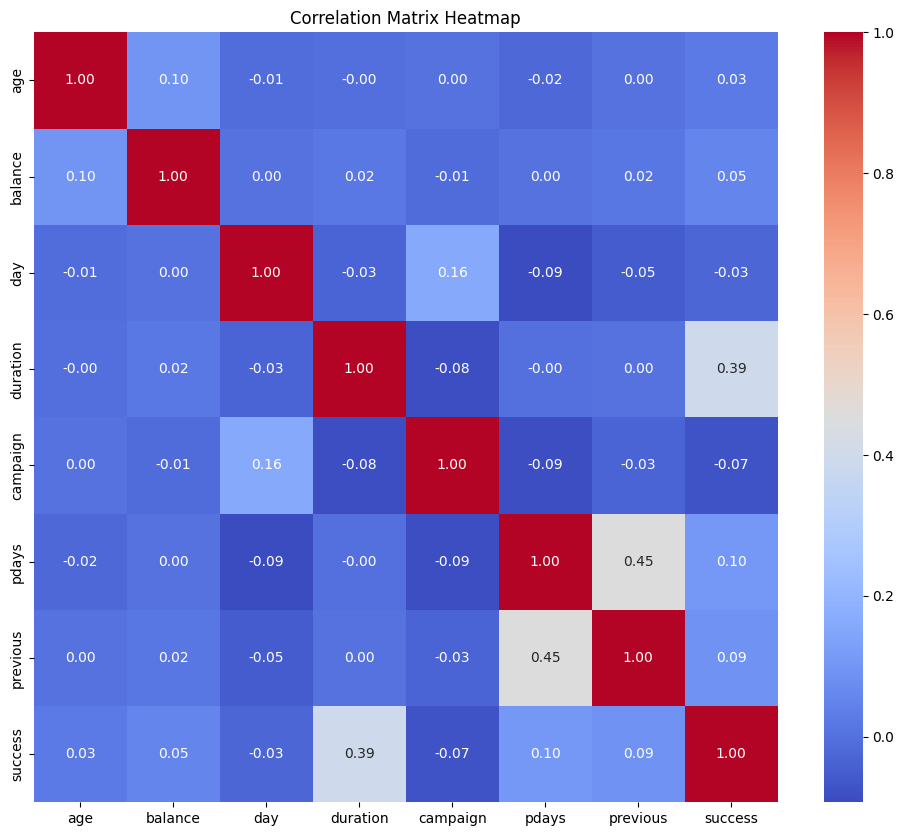

In [11]:
#Computing the correlation Matrix
numerical_features = df.select_dtypes(include=np.number).columns
correlation_matrix = df[numerical_features].corr()
# Generate a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

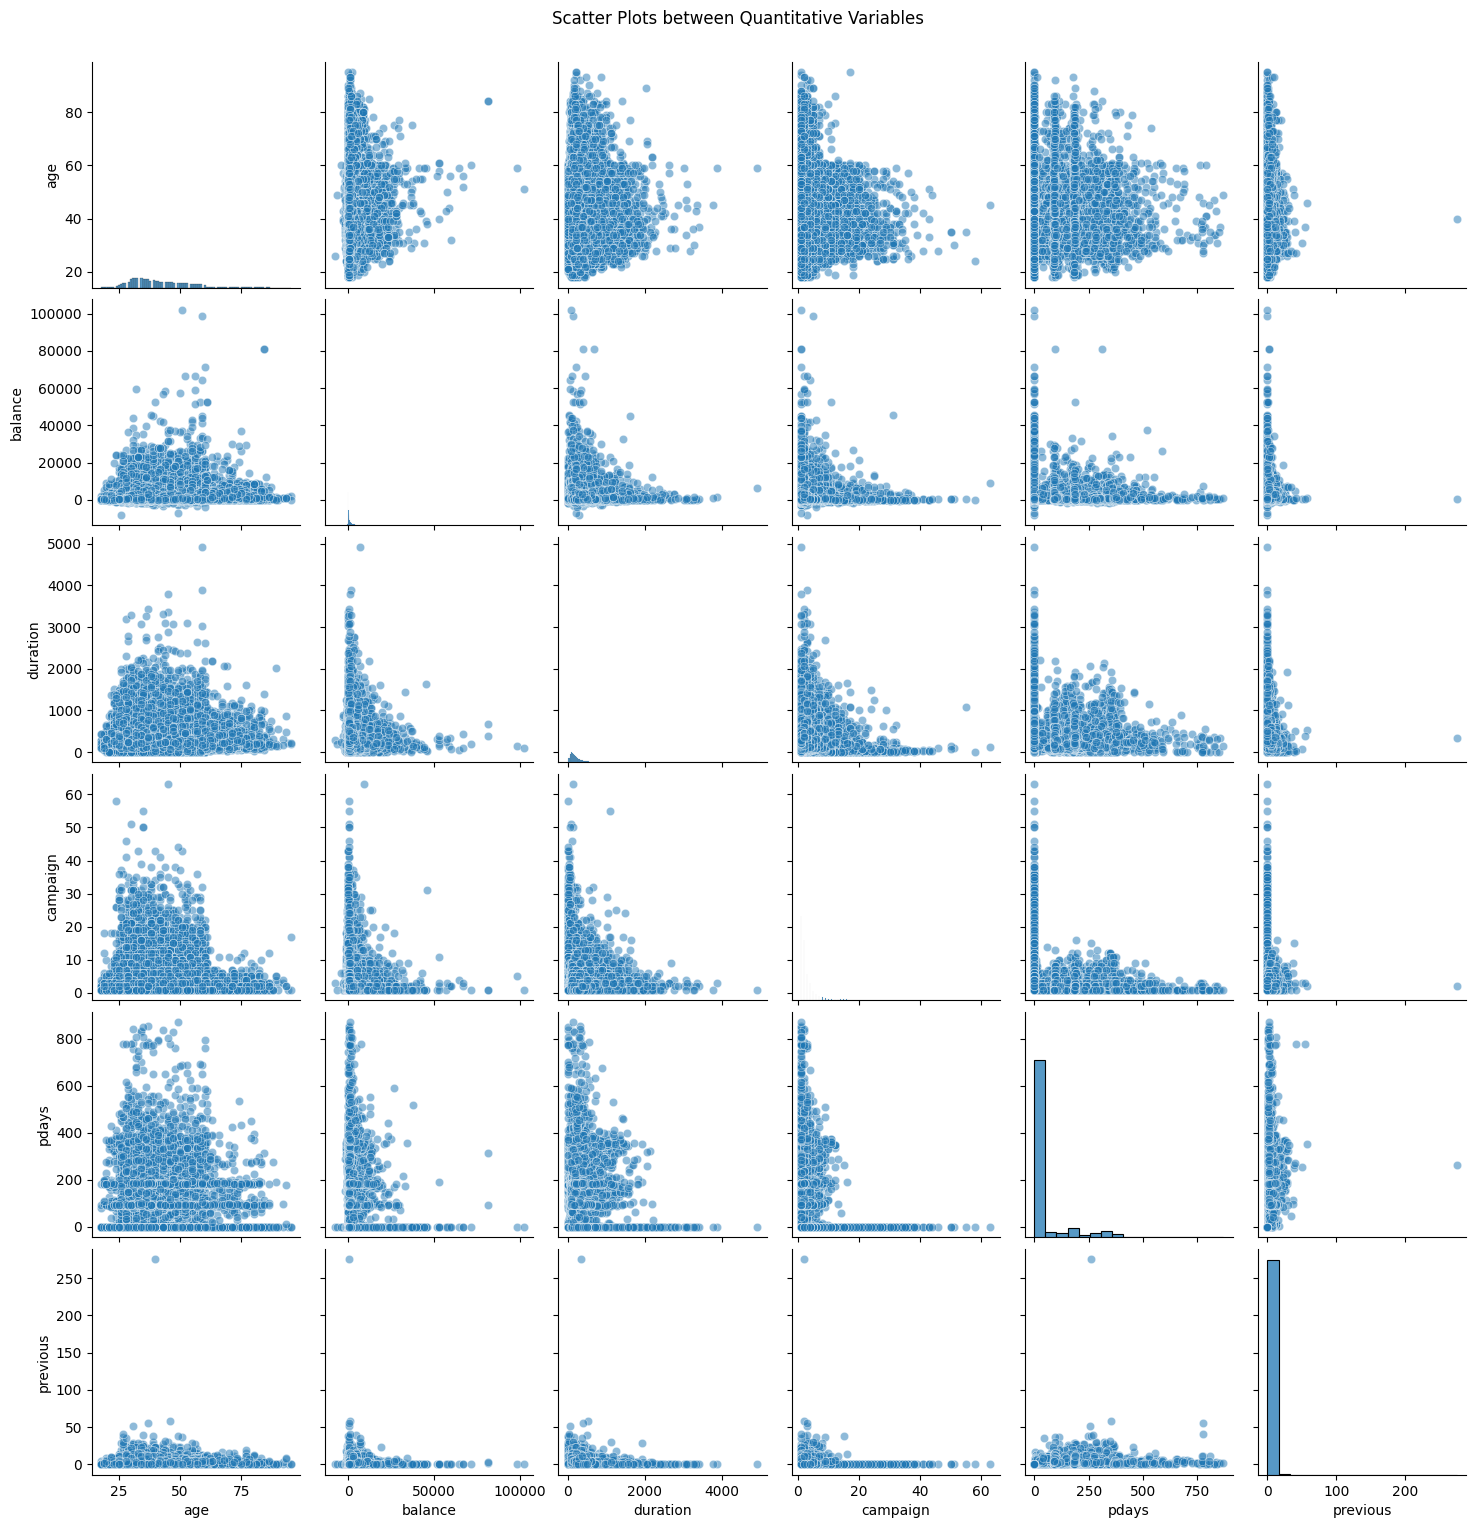

In [12]:
# Select the quantitative variables you want to plot
quantitative_vars = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

# Create a pairplot using seaborn
sns.pairplot(df[quantitative_vars], kind='scatter', diag_kind='hist', markers='o', plot_kws={'alpha': 0.5})
plt.suptitle('Scatter Plots between Quantitative Variables', y=1.02)
plt.show()

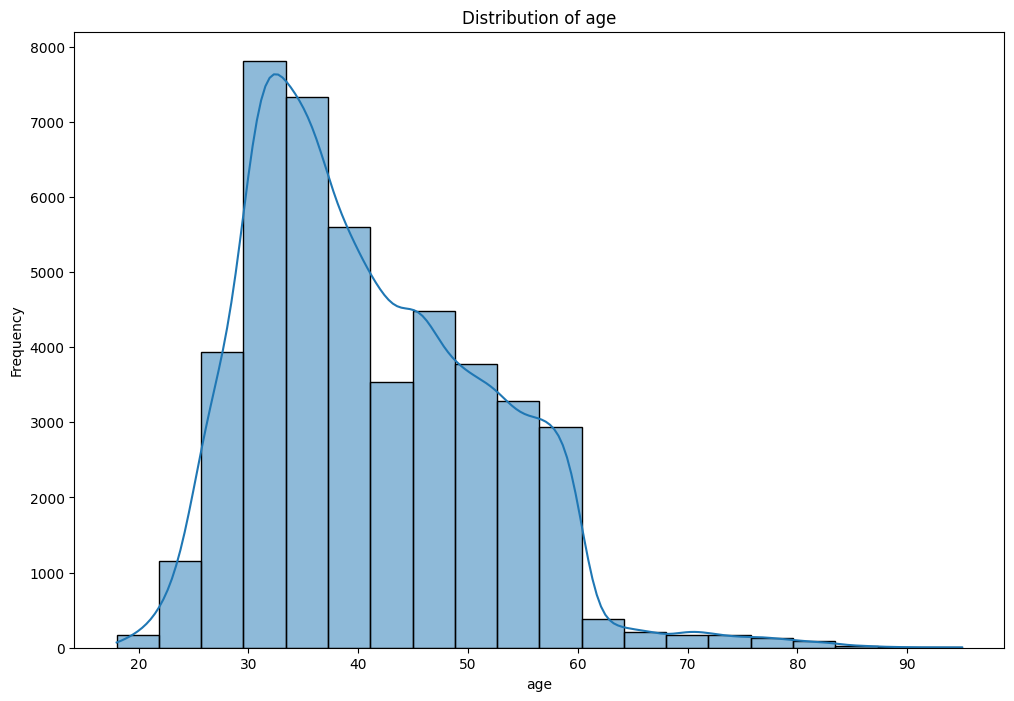

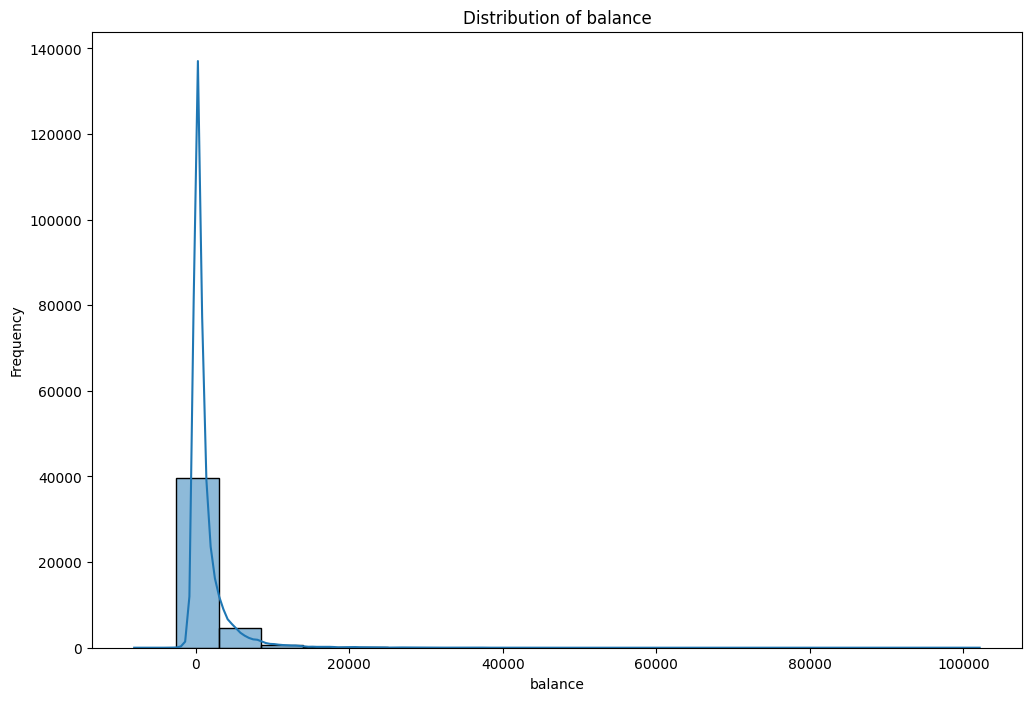

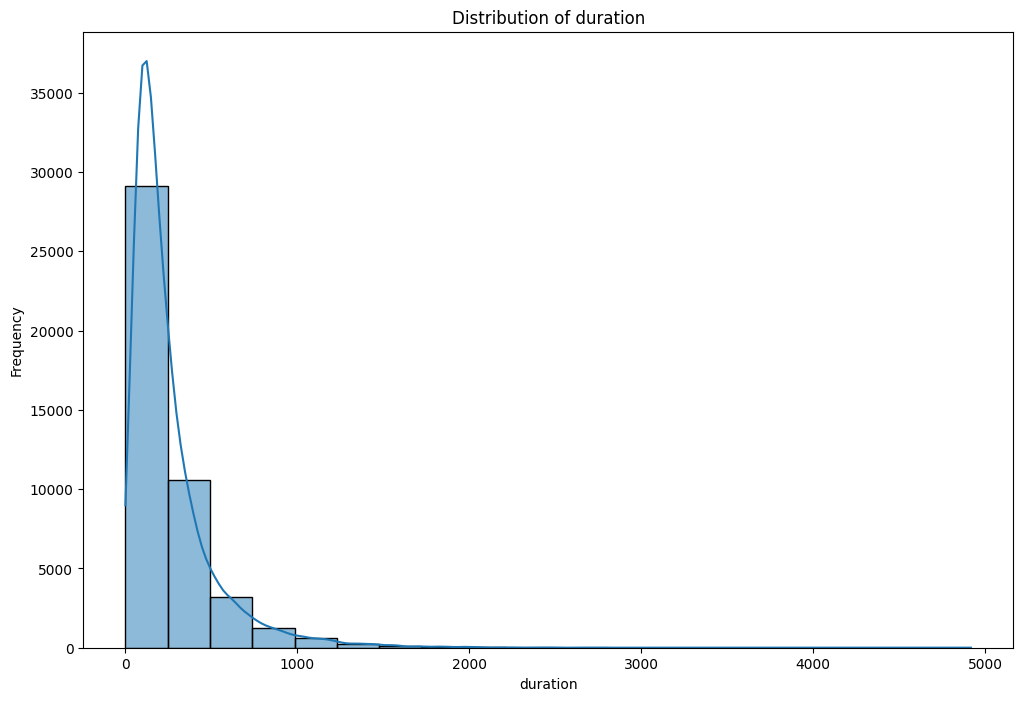

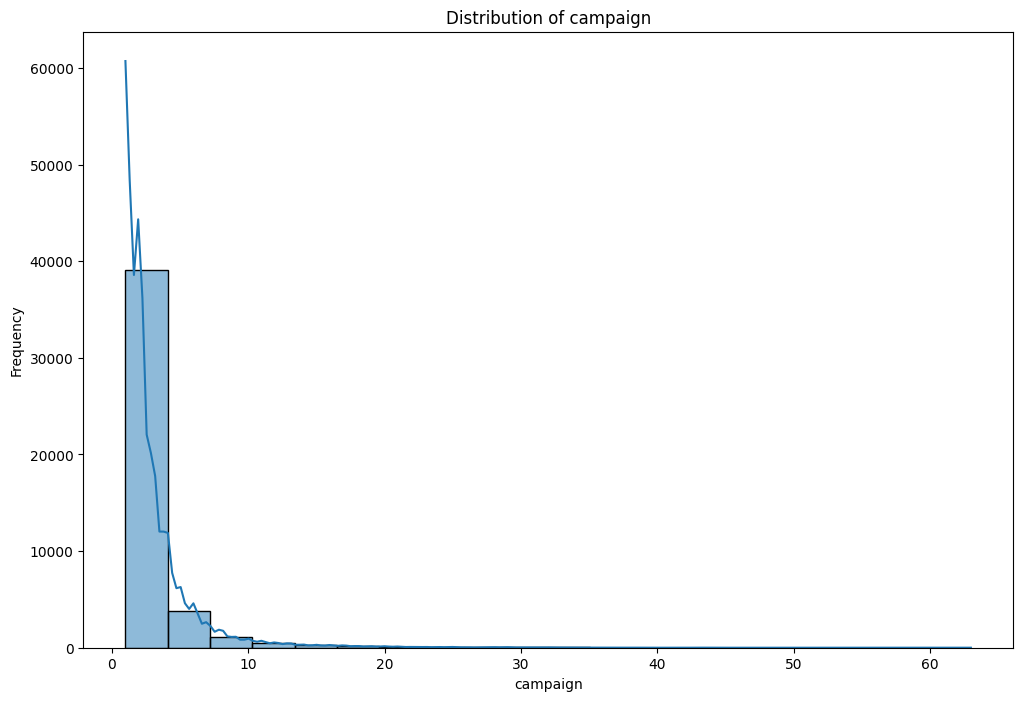

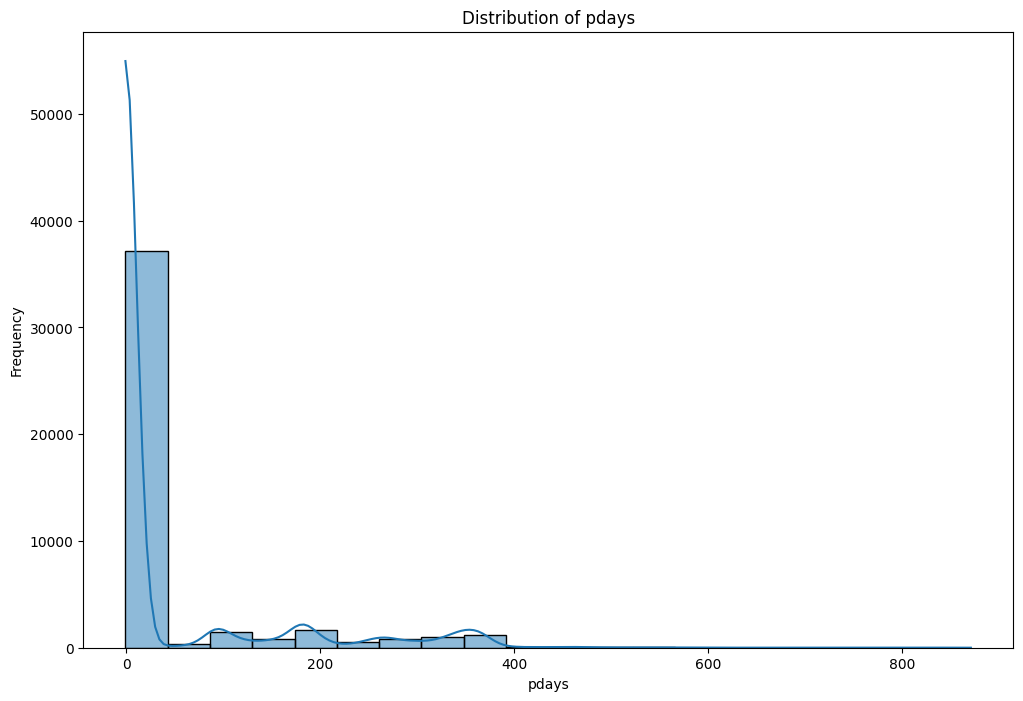

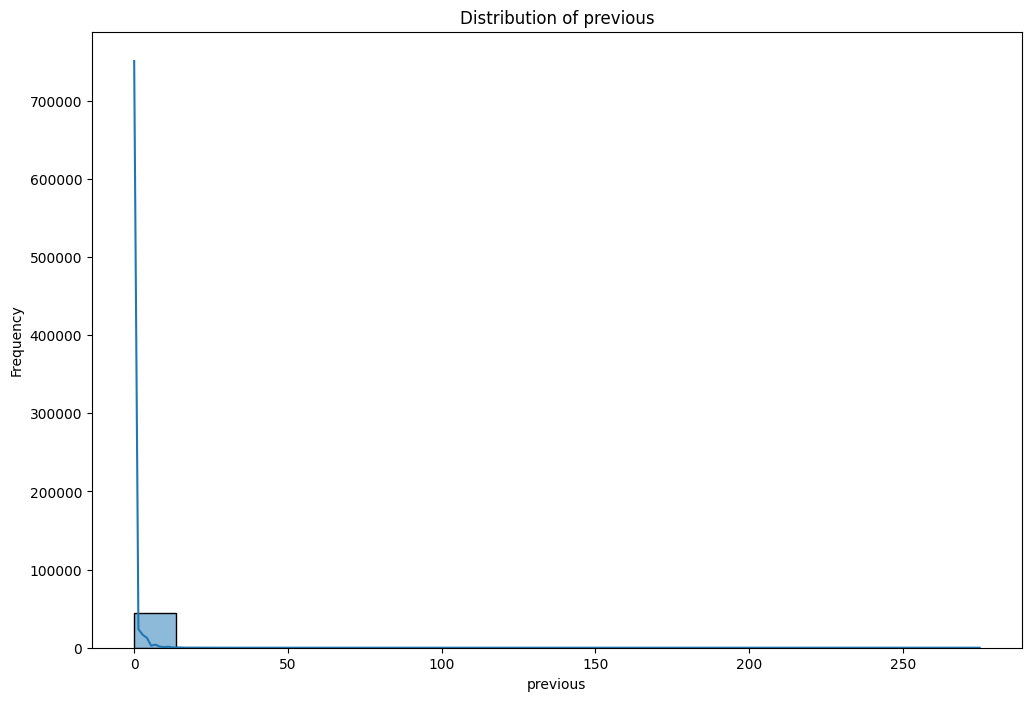

In [13]:
#Distribution of Numerical Variables
# Select the numerical features (excluding 'success' which is binary)
numerical_features = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

# Create histograms
for feature in numerical_features:
    plt.figure(figsize=(12, 8))
    sns.histplot(df[feature], bins=20, kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()


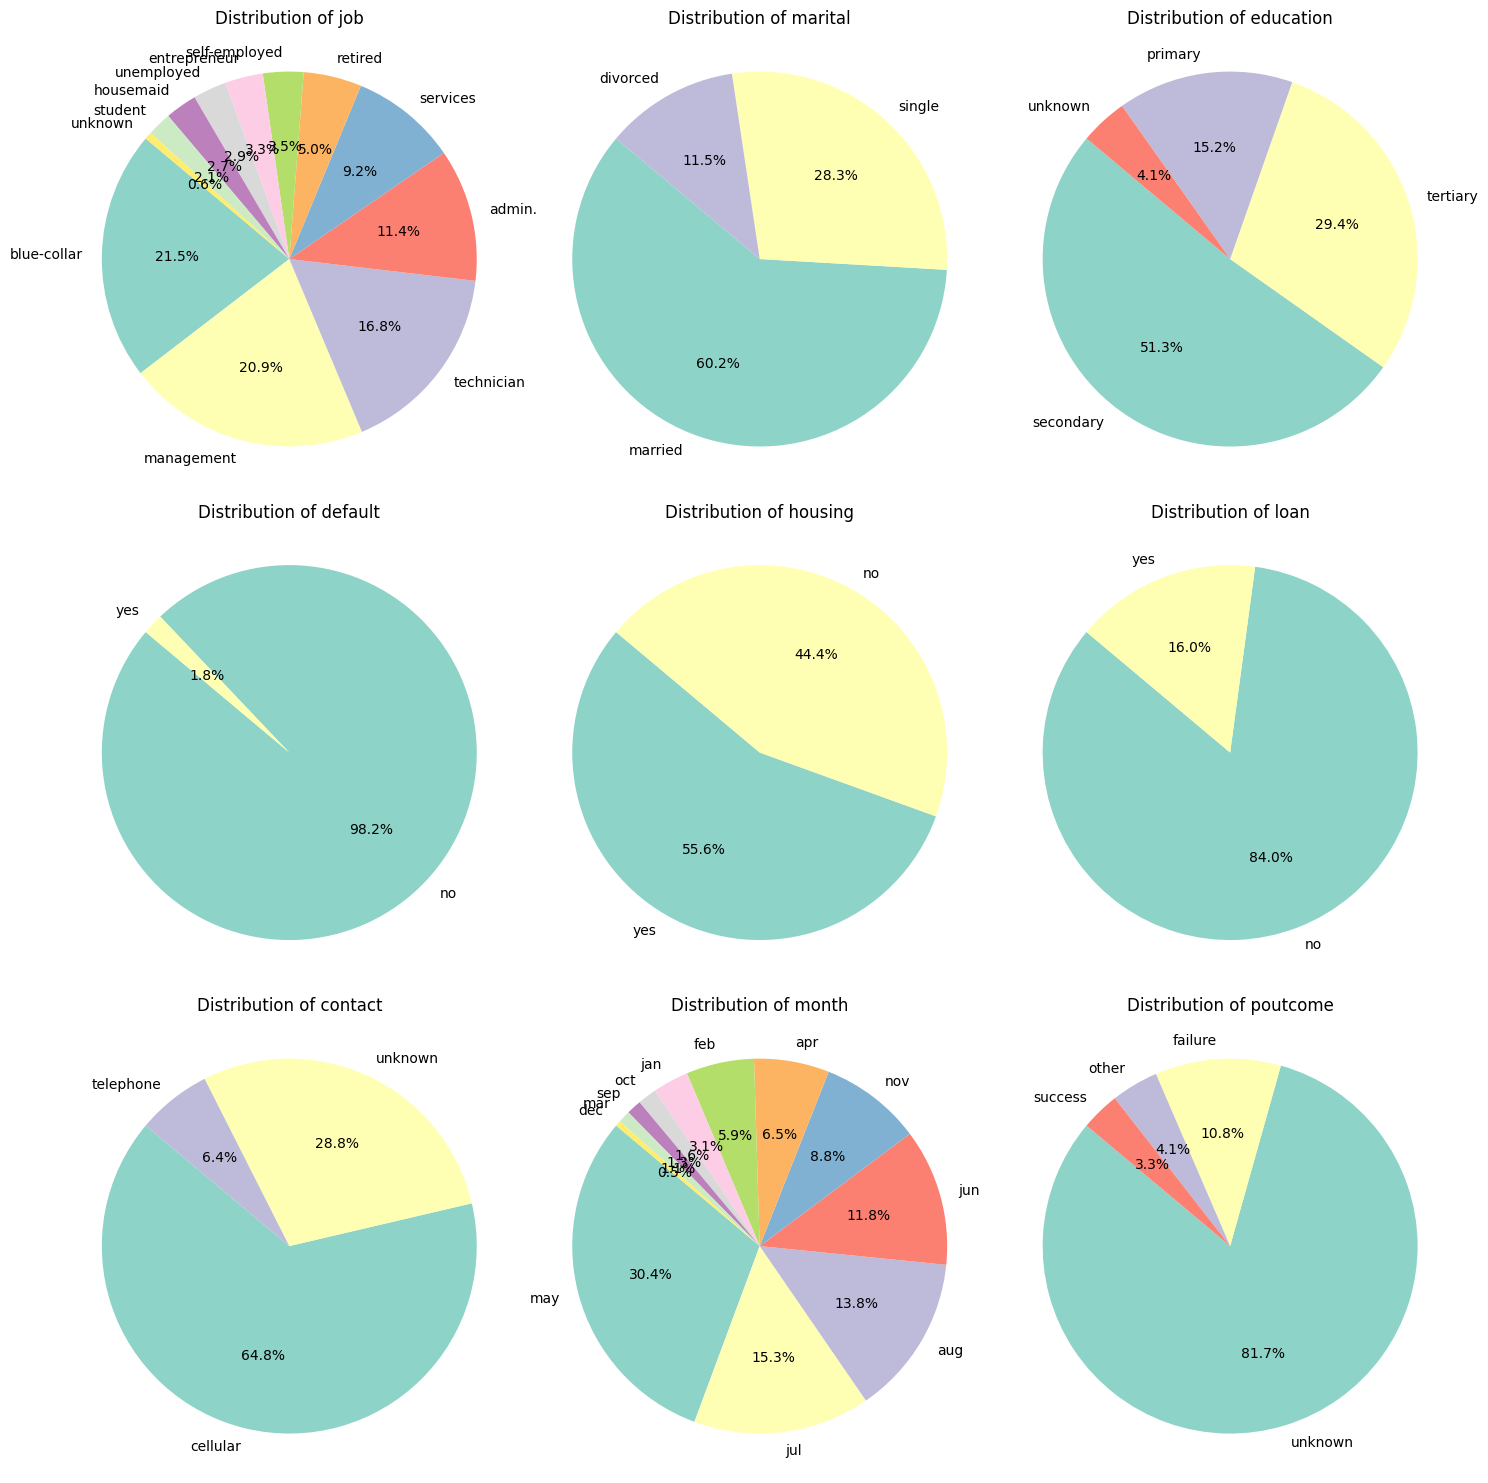

In [14]:
#Distribution of Categorical Variables
# Define categorical columns
categorical_columns = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

# Create pie charts for each categorical variable
num_cols = 3
num_rows = (len(categorical_columns) + num_cols - 1) // num_cols
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))

for i, col in enumerate(categorical_columns):
    row = i // num_cols
    col_pos = i % num_cols
    ax = axes[row, col_pos] if num_rows > 1 else axes[col_pos]

    counts = df[col].value_counts()
    ax.pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Set3.colors)
    ax.set_title(f'Distribution of {col}')
    ax.axis('equal')

# Remove unused subplots
for j in range(len(categorical_columns), num_rows * num_cols):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()

  PART 2: PROBABILITY AND DISTRIBUTION


Joint Probability Table:
education   primary  secondary  tertiary   unknown
marital                                           
divorced   0.016633   0.062264  0.032536  0.003738
married    0.116034   0.304572  0.155670  0.025657
single     0.018867   0.146358  0.105992  0.011679

Marital Marginal Probabilities:
marital
divorced    0.115171
married     0.601933
single      0.282896
dtype: float64

Education Marginal Probabilities:
education
primary      0.151534
secondary    0.513194
tertiary     0.294198
unknown      0.041074
dtype: float64

Conditional Probabilities (Education | Marital):
education   primary  secondary  tertiary   unknown
marital                                           
divorced   0.144421   0.540618  0.282504  0.032456
married    0.192768   0.505990  0.258617  0.042625
single     0.066693   0.517357  0.374668  0.041282

Conditional Probabilities (Marital | Education):
education   primary  secondary  tertiary   unknown
marital                                       

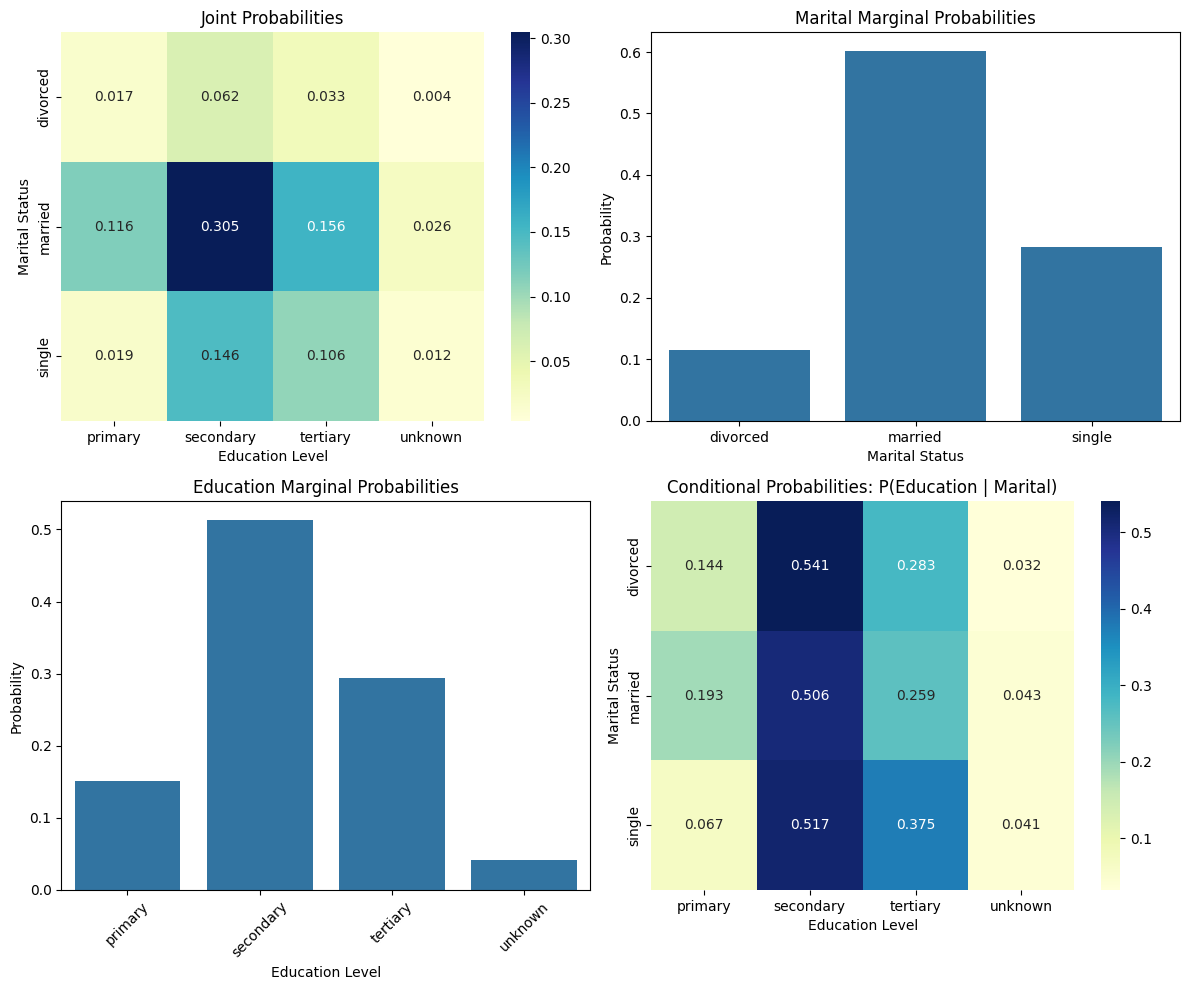

Fitted Multinomial Model Estimated_probs:
[[0.01663312 0.06226361 0.03253633 0.00373803]
 [0.11603371 0.3045719  0.15567008 0.02565747]
 [0.01886709 0.14635819 0.1059919  0.01167857]]


In [ ]:
#Probabbility for 'Marital' and 'Education'
# Joint frequency table of 'marital' and 'education'
joint_freq = pd.crosstab(df['marital'], df['education'])

# Computing Joint probability table
joint_prob = joint_freq / joint_freq.values.sum()

# Computing Marginal probabilities
marital_marginal = joint_prob.sum(axis=1)
education_marginal = joint_prob.sum(axis=0)

# Computing Conditional probabilities: P(education | marital)
cond_prob_edu_given_marital = joint_prob.div(marital_marginal, axis=0)

# Computing Conditional probabilities: P(marital | education)
cond_prob_marital_given_edu = joint_prob.div(education_marginal, axis=1)

#Listing variables
joint_prob, marital_marginal, education_marginal, cond_prob_edu_given_marital, cond_prob_marital_given_edu
#Display results
print("\nJoint Probability Table:")
print(joint_prob)

print("\nMarital Marginal Probabilities:")
print(marital_marginal)

print("\nEducation Marginal Probabilities:")
print(education_marginal)

print("\nConditional Probabilities (Education | Marital):")
print(cond_prob_edu_given_marital)

print("\nConditional Probabilities (Marital | Education):")
print(cond_prob_marital_given_edu)

#VISUALIZING PLOTS FOR VARIOUS PROBABILITIES

# Create a figure and subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # 2 rows, 2 columns of plots

# Plot Joint Probability
sns.heatmap(joint_prob, annot=True, cmap="YlGnBu", fmt=".3f", ax=axes[0, 0])
axes[0, 0].set_title("Joint Probabilities")
axes[0, 0].set_xlabel("Education Level")
axes[0, 0].set_ylabel("Marital Status")

# Plot Marital Marginal Probability
sns.barplot(x=marital_marginal.index, y=marital_marginal.values, ax=axes[0, 1])
axes[0, 1].set_title("Marital Marginal Probabilities")
axes[0, 1].set_xlabel("Marital Status")
axes[0, 1].set_ylabel("Probability")

# Plot Education Marginal Probability
sns.barplot(x=education_marginal.index, y=education_marginal.values, ax=axes[1, 0])
axes[1, 0].set_title("Education Marginal Probabilities")
axes[1, 0].set_xlabel("Education Level")
axes[1, 0].set_ylabel("Probability")
axes[1, 0].tick_params(axis='x', rotation=45)  # Rotate x-axis labels

# Plot Conditional Probability (Education | Marital)
sns.heatmap(cond_prob_edu_given_marital, annot=True, cmap="YlGnBu", fmt=".3f", ax=axes[1, 1])
axes[1, 1].set_title("Conditional Probabilities: P(Education | Marital)")
axes[1, 1].set_xlabel("Education Level")
axes[1, 1].set_ylabel("Marital Status")

# Adjust layout and display
plt.tight_layout()
plt.show()


#FITTING A MULTINOMIAL DISTRIBUTION FOR 'marital and 'education'
#Create a frequency table
freq_table = pd.crosstab(df['marital'], df['education'])

#Flatten the frequency table to get counts
marital_education_counts = freq_table.values.flatten()

#Calculate total observations
n_total = np.sum(marital_education_counts)

#Estimate probabilities for each outcome
estimated_probs = marital_education_counts / n_total

#Fit the multinomial distribution
multinomial_model = multinomial(n=n_total, p=estimated_probs)

#Display the fitted model parameters
print("Fitted Multinomial Model Estimated_probs:")
print(estimated_probs.reshape(freq_table.shape))


PART 3: INFERENCE AND HYPOTHESIS TESTING

In [15]:
# A TWO SAMPLE T-TEST
job_type1 = 'management'
job_type2 = 'technician'

# Filter the DataFrame for the selected job types
group1 = df[df['job'] == job_type1]['success']
group2 = df[df['job'] == job_type2]['success']

# Perform the two-sample t-test
t_statistic, p_value = stats.ttest_ind(group1, group2)

# Print the results
print(f"T-statistic: {t_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

# Interpret the results
alpha = 0.05  # Significance level
if p_value < alpha:
    print(f"There is a significant difference in campaign success between {job_type1} and {job_type2} (p < {alpha}).")
else:
    print(f"There is no significant difference in campaign success between {job_type1} and {job_type2} (p >= {alpha}).")

T-statistic: 5.29
P-value: 0.000
There is a significant difference in campaign success between management and technician (p < 0.05).


In [ ]:
#A CHI-SQUARE GOODNESS-OF-FIT TEST FOR CATEGORICAL VARIABLE "MARITAL"

#Get observed frequencies of the marital variable
observed = df['marital'].value_counts().sort_index()
print("Observed frequencies:")
print(observed)

#Define expected frequencies
n = observed.sum()
expected = [n / len(observed)] * len(observed)

#Chi-Square Goodness-of-Fit Test
chi_stat, p_value = stats.chisquare(f_obs=observed, f_exp=expected)

#Display results
print("\nExpected frequencies (Uniform):")
print(dict(zip(observed.index, expected)))

print(f"\nChi-square statistic: {chi_stat:.3f}")
print(f"P-value: {p_value:.4f}")

#Interpretation
alpha = 0.05
if p_value < alpha:
    print("Statistically significant difference: the marital status distribution is NOT uniform.")
else:
    print("No statistically significant difference: the marital status distribution could be uniform.")


Observed frequencies:
marital
divorced     5207
married     27214
single      12790
Name: count, dtype: int64

Expected frequencies (Uniform):
{'divorced': np.float64(15070.333333333334), 'married': np.float64(15070.333333333334), 'single': np.float64(15070.333333333334)}

Chi-square statistic: 16585.825
P-value: 0.0000
Statistically significant difference: the marital status distribution is NOT uniform.


In [16]:
#95% CONFIDENCE INTERVAL FOR CAMPAIGN SUCESS RATE

# Calculate overall success rate and sample size
success_rate = df['success'].mean()
n = len(df)

# Calculate the standard error
standard_error = np.sqrt(success_rate * (1 - success_rate) / n)

# Calculate the margin of error (for 95% confidence interval)
margin_of_error = stats.norm.ppf(0.975) * standard_error  # ppf(0.975) gives the z-score for 95% confidence

# Calculate the confidence interval
lower_bound = success_rate - margin_of_error
upper_bound = success_rate + margin_of_error

# Print the results
print(f"Overall Campaign Success Rate: {success_rate:.2f}")
print(f"95% Confidence Interval: ({lower_bound:.2f}, {upper_bound:.2f})")

# Interpretation
print("\nInterpretation:")
print(f"The 95% confident that the true campaign success rate for the entire population lies between {lower_bound:.2f} and {upper_bound:.2f}.")

Overall Campaign Success Rate: 0.12
95% Confidence Interval: (0.11, 0.12)

Interpretation:
The 95% confident that the true campaign success rate for the entire population lies between 0.11 and 0.12.


Part IV: BAYESIAN ANALYSIS

Posterior Distribution: Beta(5290, 39923)
95% Credible Interval: (0.11, 0.120)
Estimated Probability of Subscription: 0.117


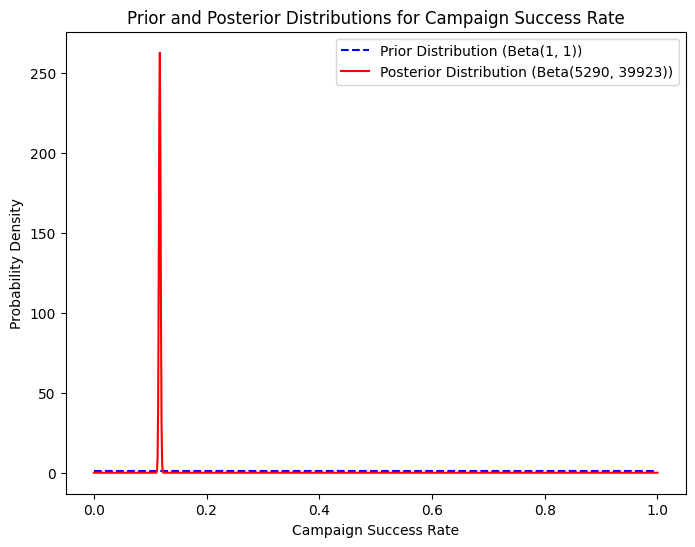

In [ ]:
#Define Prior Distribution (Beta Distribution)
# Using uninformed prior (Beta(1, 1)), representing no prior knowledge.
alpha_prior = 1
beta_prior = 1

#Update with Observed Data and Calculate the number of successes(subscription) and failures(no subscription)
successes = df['success'].sum() ## Sum of successes (success = 1)
failures = len(df)-successes #Total observations minus successes

# Update the prior parameters with observed data
alpha_posterior = alpha_prior + successes
beta_posterior = beta_prior + failures

#Calculate Posterior Distribution and Credible Interval
#The posterior distribution is also a Beta distribution
posterior_dist = beta(alpha_posterior, beta_posterior)

# Calculate the 95% credible interval
lower_bound = posterior_dist.ppf(0.025)  # 2.5th percentile
upper_bound = posterior_dist.ppf(0.975)  # 97.5th percentile

# Print the results
print(f"Posterior Distribution: Beta({alpha_posterior}, {beta_posterior})")
print(f"95% Credible Interval: ({lower_bound:.2f}, {upper_bound:.3f})")

#Estimate the probability (mean of the posterior distribution)
estimated_probability = posterior_dist.mean()
print(f"Estimated Probability of Subscription: {estimated_probability:.3f}")

#Visualize Prior and Posterior Distributions
# Create a range of x values for the plot
x = np.linspace(0, 1, 1000)

# Calculate the probability density function (PDF) for the prior and posterior
prior_pdf = beta.pdf(x, alpha_prior, beta_prior)
posterior_pdf = beta.pdf(x, alpha_posterior, beta_posterior)

# Plot the prior and posterior distributions
plt.figure(figsize=(8, 6))
plt.plot(x, prior_pdf, label='Prior Distribution (Beta(1, 1))', color='blue', linestyle='--')
plt.plot(x, posterior_pdf, label=f'Posterior Distribution (Beta({alpha_posterior}, {beta_posterior}))', color='red')

plt.title('Prior and Posterior Distributions for Campaign Success Rate')
plt.xlabel('Campaign Success Rate')
plt.ylabel('Probability Density')
plt.legend()
plt.show()



PART V: A/B TESTING

In [17]:
# Simulate Marketing Strategies
# Randomly assign customers to either phone call or email strategy.
np.random.seed(42)  # For reproducibility
df['marketing_strategy'] = np.random.choice(['phone_call', 'email'], size=len(df))


# Creating Subset Data for Each Strategy
phone_call_group = df[df['marketing_strategy'] == 'phone_call']
email_group = df[df['marketing_strategy'] == 'email']

# Calculate Success Rates for Each Group
phone_call_success_rate = phone_call_group['success'].mean()  # Calculate mean success rate for phone calls
email_success_rate = email_group['success'].mean()  # Calculate mean success rate for emails

#Perform A/B Test (Two-Proportion Z-Test)
# Calculate the pooled proportion
pooled_proportion = (phone_call_group['success'].sum() + email_group['success'].sum()) / (len(phone_call_group) + len(email_group))
# Calculate the standard error
se = np.sqrt(pooled_proportion * (1 - pooled_proportion) * (1 / len(phone_call_group) + 1 / len(email_group)))

# Calculate the z-score
z_score = (phone_call_success_rate - email_success_rate) / se

# Calculate the p-value (two-tailed test)
p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))

# Print and Interpret Results
alpha = 0.05  # Significance level
print(f"Phone Call Success Rate: {phone_call_success_rate:.4f}")
print(f"Email Success Rate: {email_success_rate:.4f}")
print(f"Z-score: {z_score:.4f}")
print(f"P-value: {p_value:.4f}")


if p_value < alpha:
    print("There is a statistically significant difference between the two marketing strategies (p < 0.05).")
else:
    print("There is no statistically significant difference between the two marketing strategies (p >= 0.05).")

if phone_call_success_rate > email_success_rate:
        print("Phone calls are more effective.")
else:
    print("Emails are more effective.")

Phone Call Success Rate: 0.1176
Email Success Rate: 0.1164
Z-score: 0.3831
P-value: 0.7016
There is no statistically significant difference between the two marketing strategies (p >= 0.05).
Phone calls are more effective.


PART VI:  LOGISTICS REGRESSION

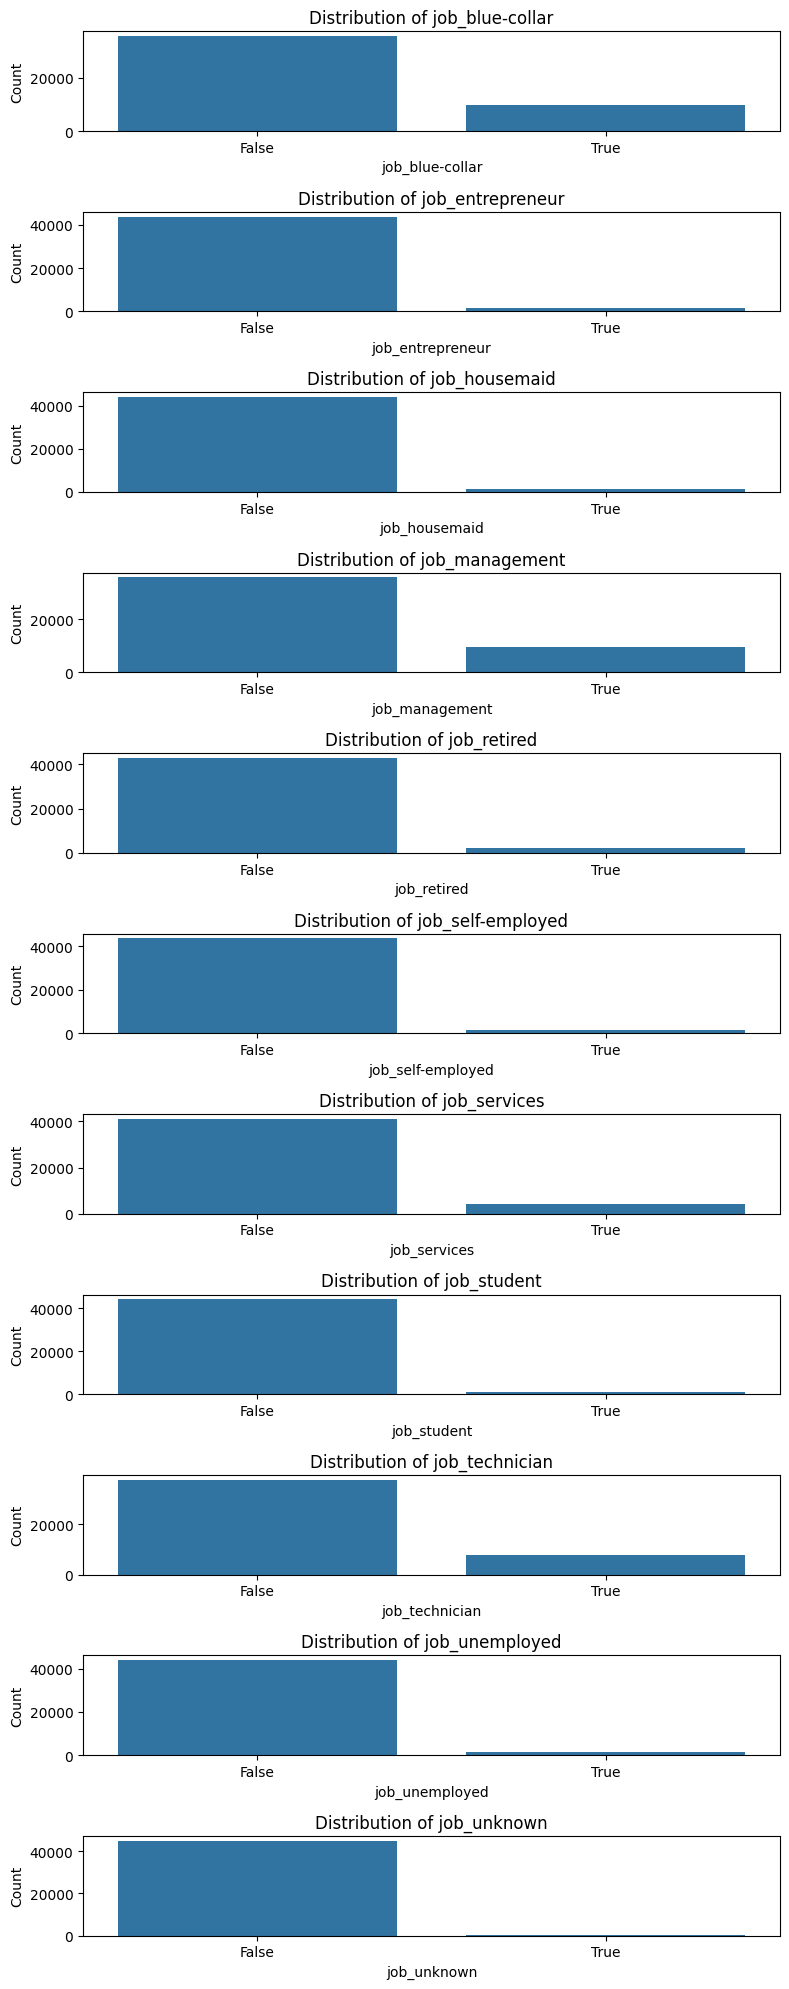

In [18]:
#APPLYING ONE-HOT ENCODING METHOD TO ALL CATEGORICAL VARIABLES
#Perform One-Hot Encoding for 'job'
encoded_df = pd.get_dummies(df, columns=['job'], drop_first=True)

# Get the new encoded columns for 'job' # This line is crucial
encoded_columns = [col for col in encoded_df.columns if 'job' in col]

# Create a subplot for each selected column
fig, axes = plt.subplots(len(encoded_columns), 1, figsize=(8, 20))

for i, col in enumerate(encoded_columns):
    sns.countplot(x=col, data=encoded_df, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

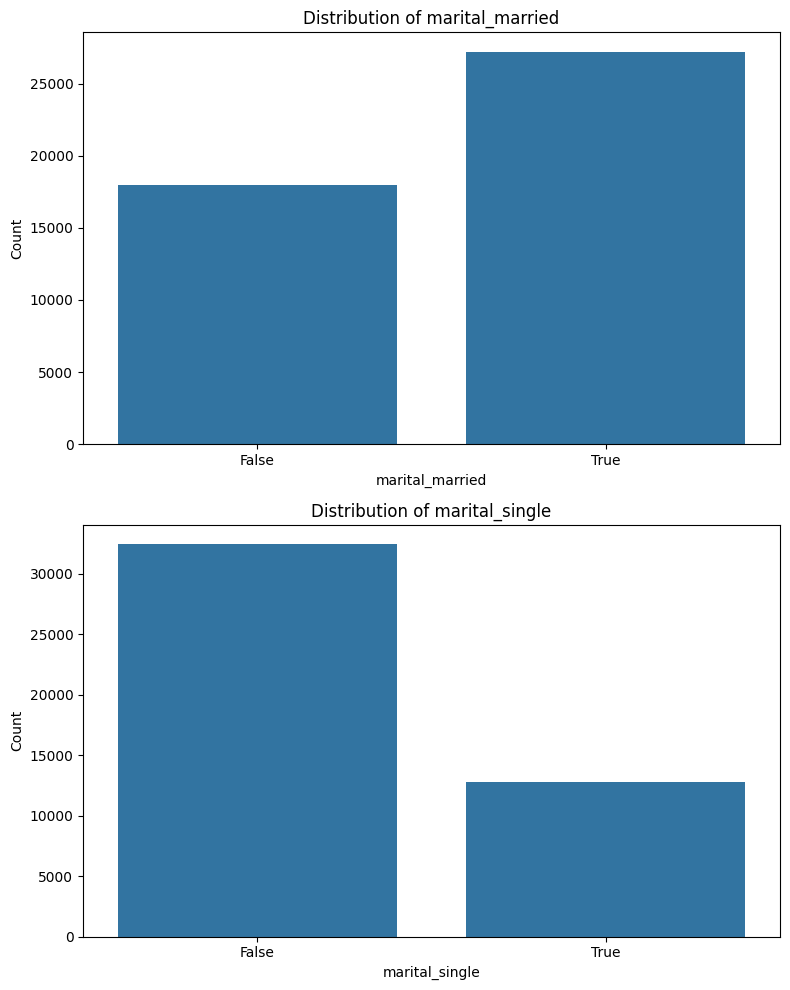

In [19]:
#Perform One-Hot Encoding for 'marital'
encoded_df = pd.get_dummies(df, columns=['marital'], drop_first=True)

# Get the new encoded columns for 'marital' # This line is crucial
encoded_columns = [col for col in encoded_df.columns if 'marital' in col]

# Create a subplot for each selected column
fig, axes = plt.subplots(len(encoded_columns), 1, figsize=(8, 10))

for i, col in enumerate(encoded_columns):
    sns.countplot(x=col, data=encoded_df, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

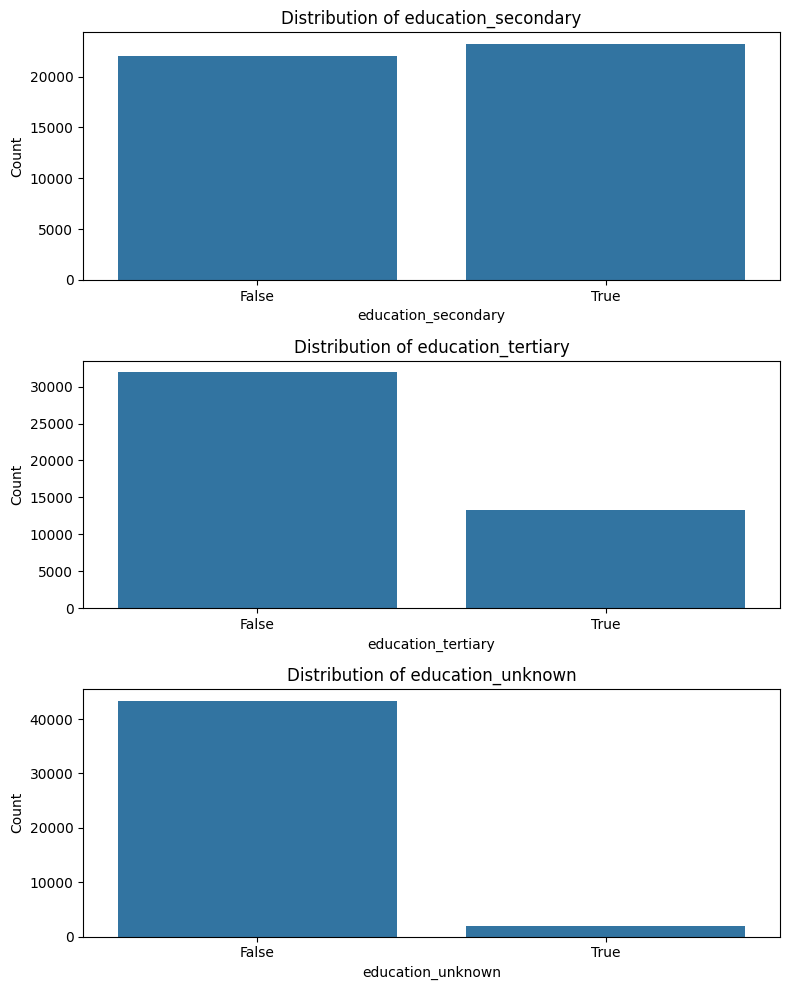

In [20]:
#Perform One-Hot Encoding for 'education'
encoded_df = pd.get_dummies(df, columns=['education'], drop_first=True)

# Get the new encoded columns for 'marital' # This line is crucial
encoded_columns = [col for col in encoded_df.columns if 'education' in col]

# Create a subplot for each selected column
fig, axes = plt.subplots(len(encoded_columns), 1, figsize=(8, 10))

for i, col in enumerate(encoded_columns):
    sns.countplot(x=col, data=encoded_df, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()


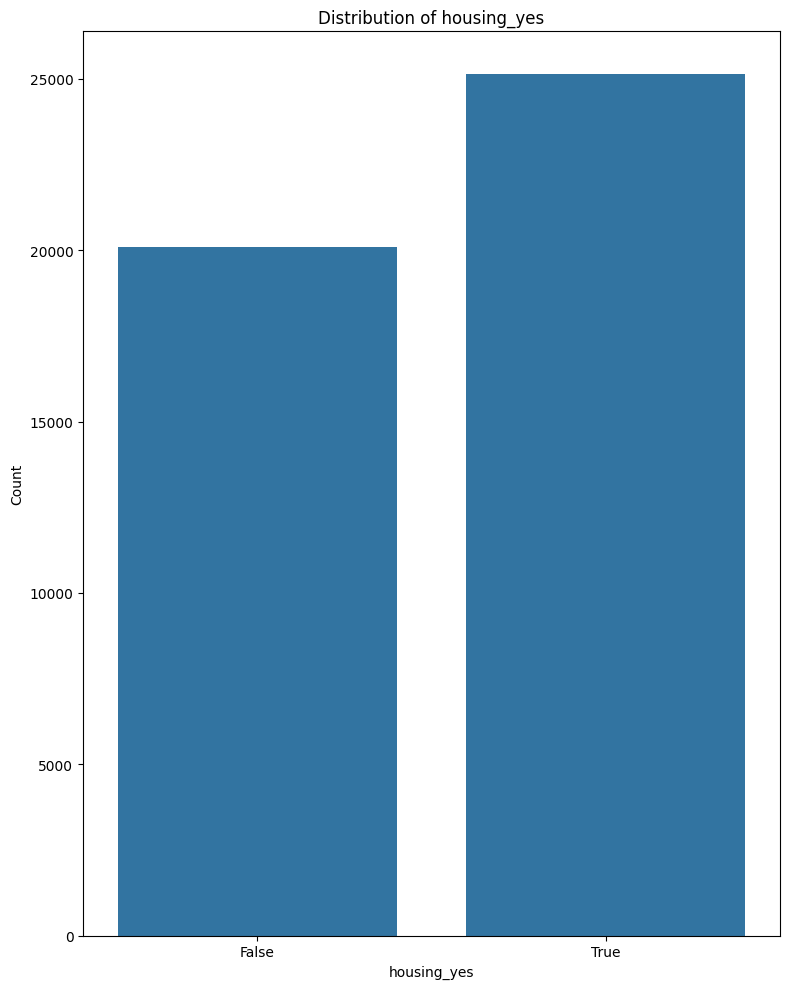

In [21]:
#Perform One-Hot Encoding for 'education'
encoded_df = pd.get_dummies(df, columns=['housing'], drop_first=True)

# Get the new encoded columns for 'marital' # This line is crucial
encoded_columns = [col for col in encoded_df.columns if 'housing' in col]

# Create a subplot for each selected column
fig, axes = plt.subplots(len(encoded_columns), 1, figsize=(8, 10))

for i, col in enumerate(encoded_columns):
    sns.countplot(x=col, data=encoded_df, ax=axes)
    axes.set_title(f'Distribution of {col}')
    axes.set_xlabel(col)
    axes.set_ylabel('Count')

plt.tight_layout()
plt.show()

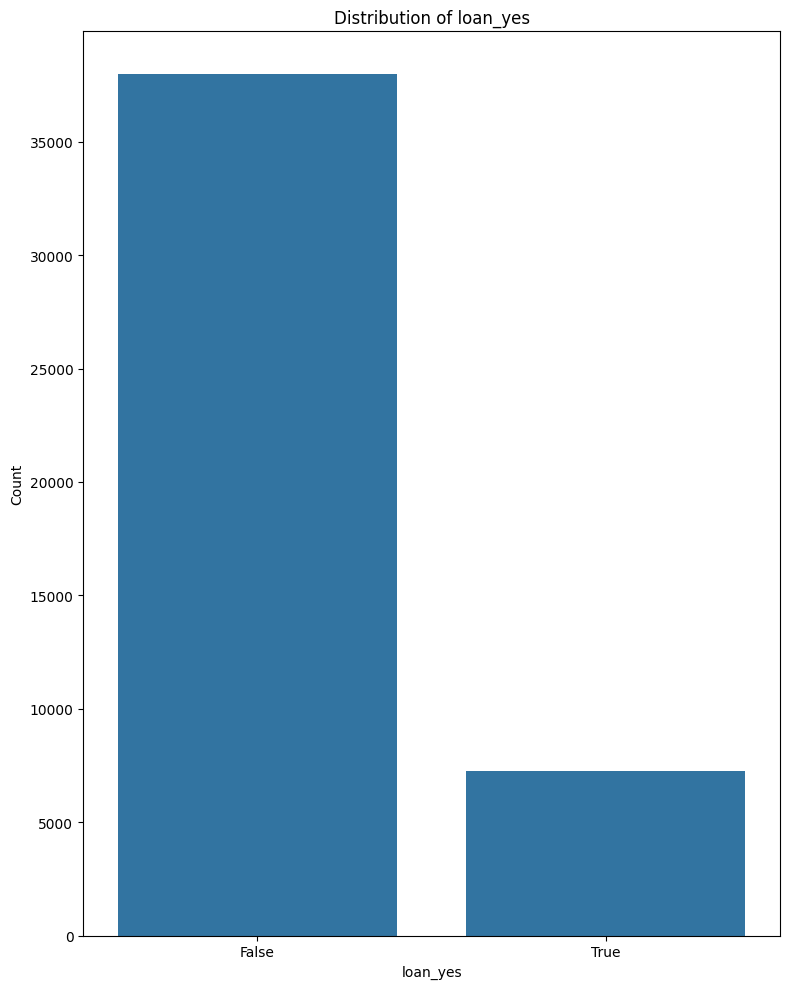

In [22]:
#Perform One-Hot Encoding for 'education'
encoded_df = pd.get_dummies(df, columns=['loan'], drop_first=True)

# Get the new encoded columns for 'marital' # This line is crucial
encoded_columns = [col for col in encoded_df.columns if 'loan' in col]

# Create a subplot for each selected column
fig, axes = plt.subplots(len(encoded_columns), 1, figsize=(8, 10))

for i, col in enumerate(encoded_columns):
    sns.countplot(x=col, data=encoded_df, ax=axes)
    axes.set_title(f'Distribution of {col}')
    axes.set_xlabel(col)
    axes.set_ylabel('Count')

plt.tight_layout()
plt.show()

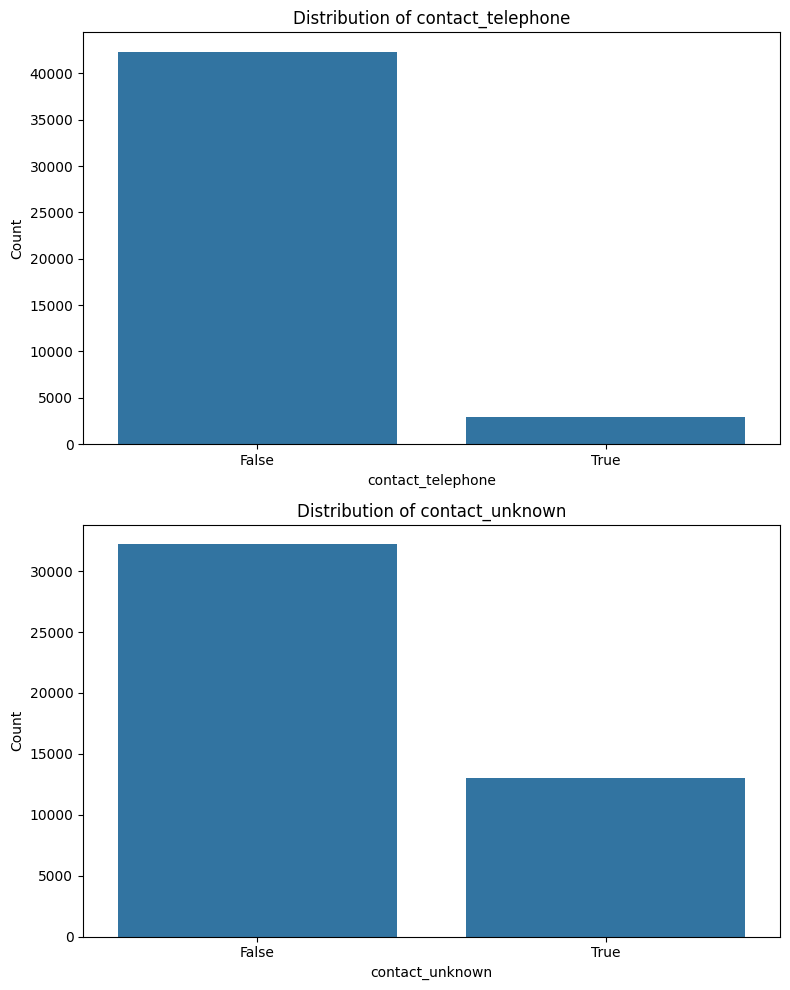

In [23]:
#Perform One-Hot Encoding for 'contact'
encoded_df = pd.get_dummies(df, columns=['contact'], drop_first=True)

# Get the new encoded columns for 'marital' # This line is crucial
encoded_columns = [col for col in encoded_df.columns if 'contact' in col]

# Create a subplot for each selected column
fig, axes = plt.subplots(len(encoded_columns), 1, figsize=(8, 10))

for i, col in enumerate(encoded_columns):
    sns.countplot(x=col, data=encoded_df, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

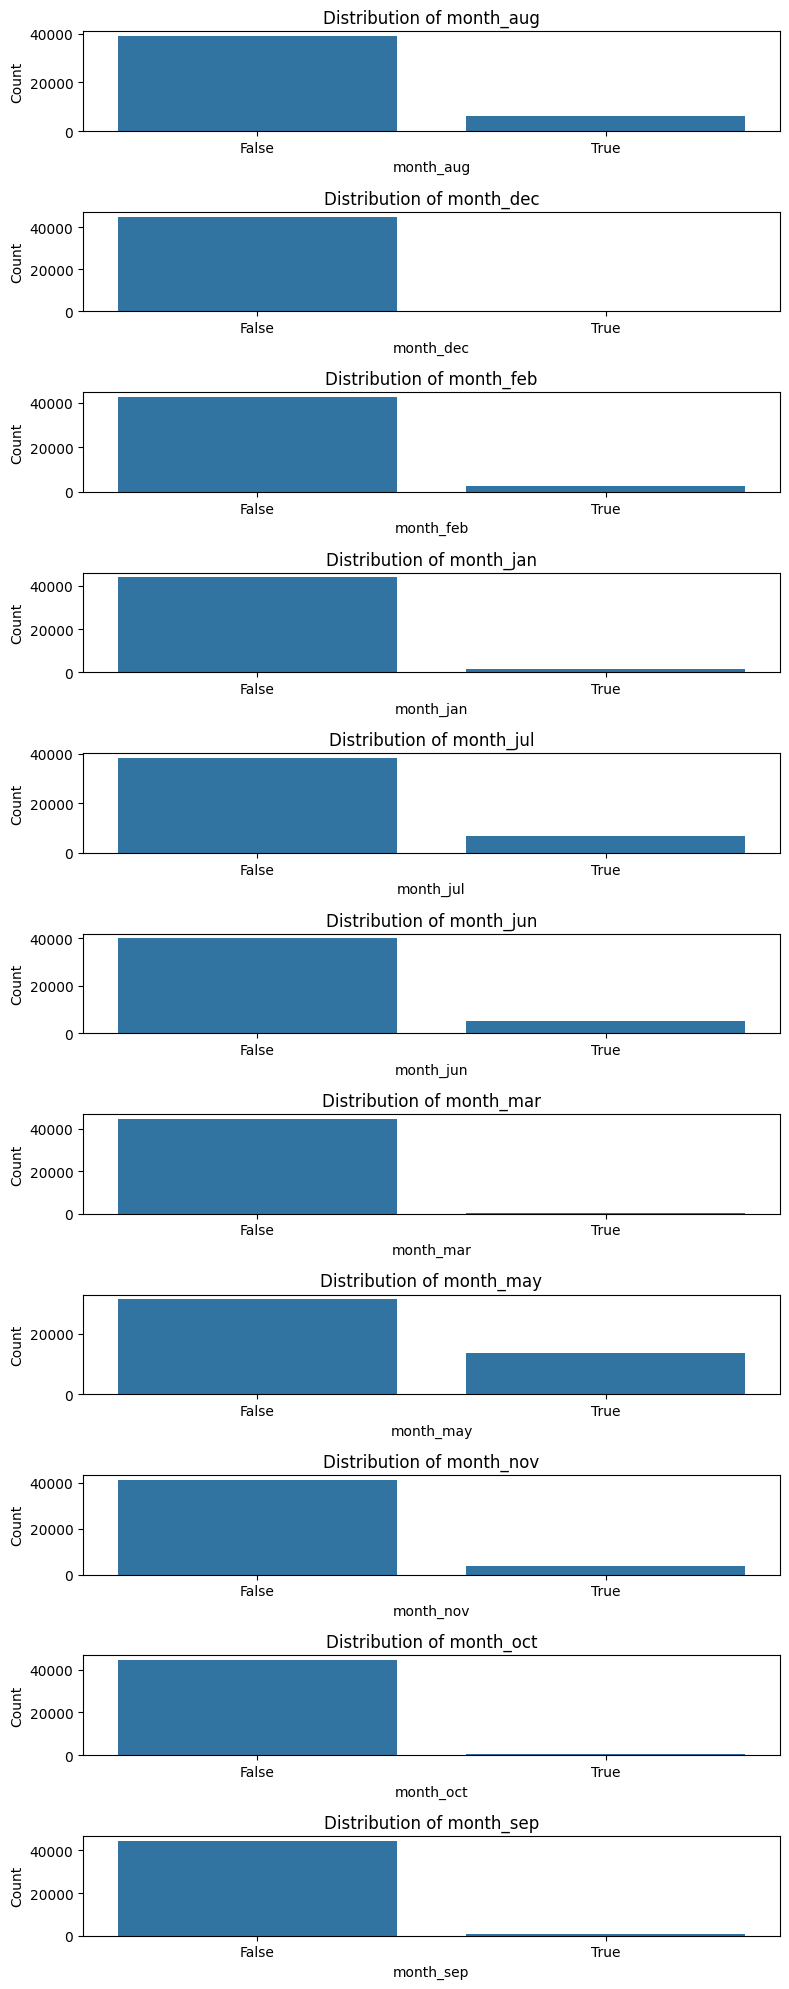

In [24]:
#Perform One-Hot Encoding for 'month'
encoded_df = pd.get_dummies(df, columns=['month'], drop_first=True)

# Get the new encoded columns for 'marital' # This line is crucial
encoded_columns = [col for col in encoded_df.columns if 'month' in col]

# Create a subplot for each selected column
fig, axes = plt.subplots(len(encoded_columns), 1, figsize=(8, 20))

for i, col in enumerate(encoded_columns):
    sns.countplot(x=col, data=encoded_df, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
plt.tight_layout()
plt.show()

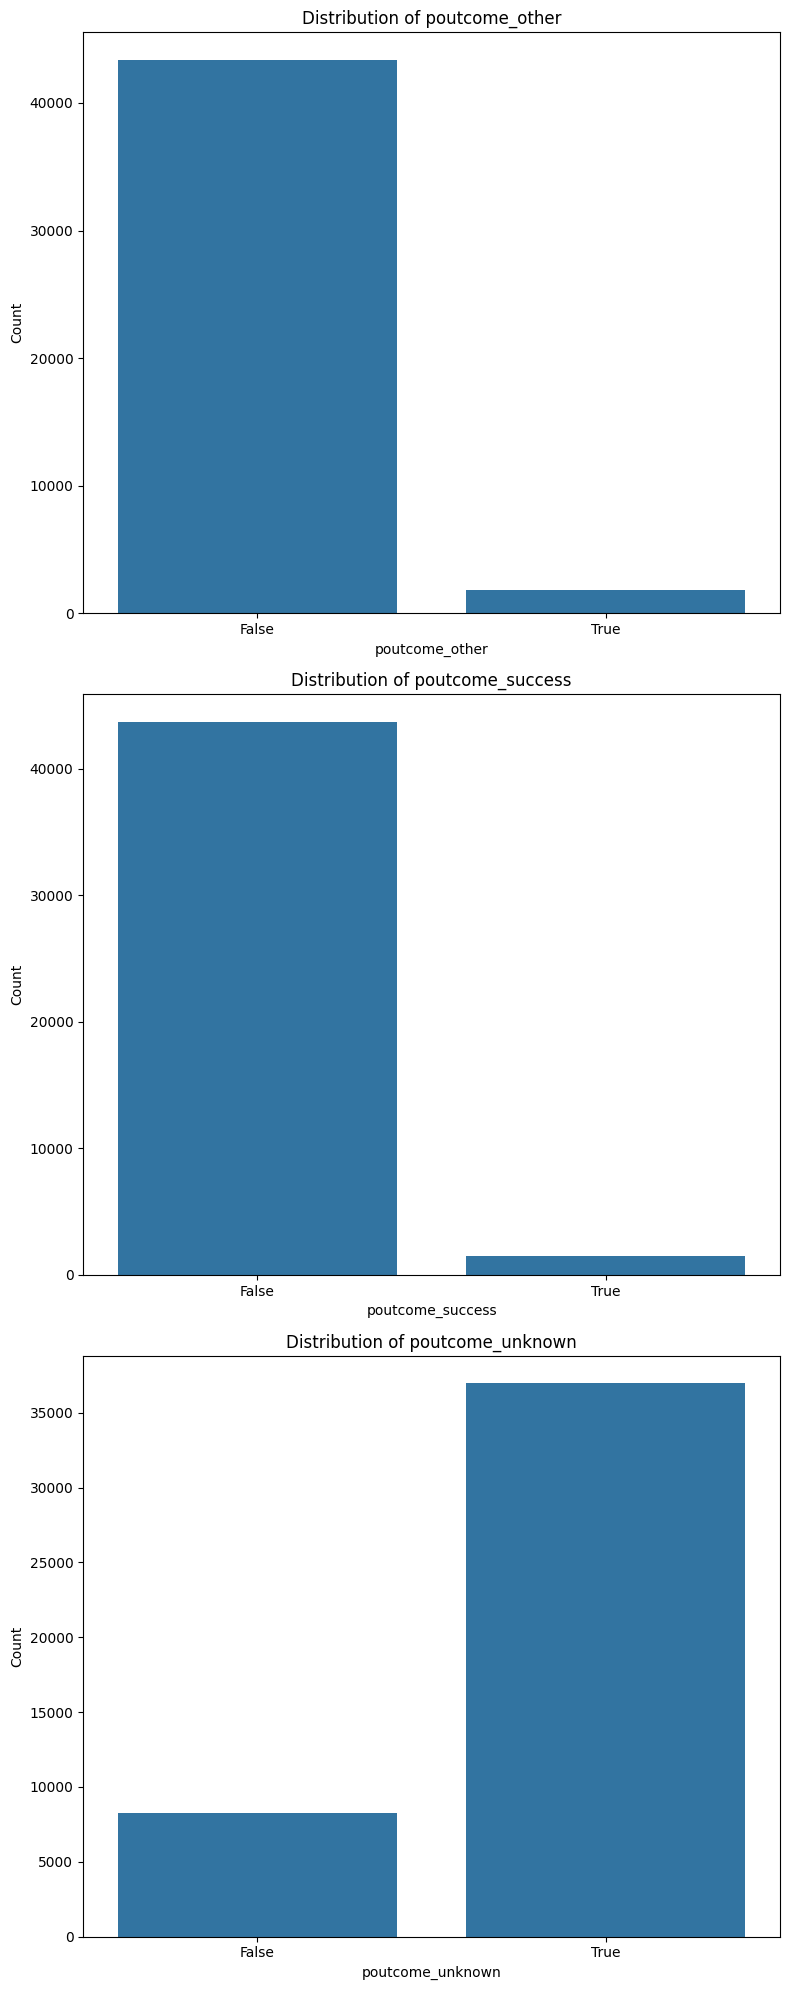

In [25]:
#Perform One-Hot Encoding for 'poutcome'
encoded_df = pd.get_dummies(df, columns=['poutcome'], drop_first=True)

# Get the new encoded columns for 'marital' # This line is crucial
encoded_columns = [col for col in encoded_df.columns if 'poutcome' in col]

# Create a subplot for each selected column
fig, axes = plt.subplots(len(encoded_columns), 1, figsize=(8, 20))

for i, col in enumerate(encoded_columns):
    sns.countplot(x=col, data=encoded_df, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
plt.tight_layout()
plt.show()

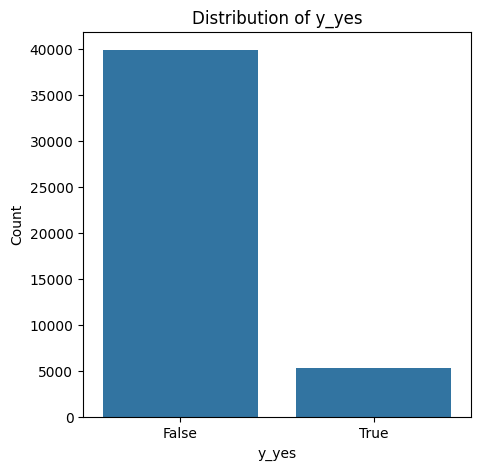

In [26]:
# Perform One-Hot Encoding for 'y'
encoded_df = pd.get_dummies(df, columns=['y'], prefix='y', drop_first=True)

# Get the new encoded column for 'y'
encoded_column = 'y_yes'  # Taking 'yes' to be positive outcome

# Create a countplot for the encoded column
plt.figure(figsize=(5, 5))
sns.countplot(x=encoded_column, data=encoded_df)
plt.title(f'Distribution of {encoded_column}')
plt.xlabel(encoded_column)
plt.ylabel('Count')
plt.show()

Coefficients: 0.0026
Intercept: -0.9904

Accuracy: 0.821
Confusion Matrix:
 [[6632 1372]
 [ 243  796]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.83      0.89      8004
           1       0.37      0.77      0.50      1039

    accuracy                           0.82      9043
   macro avg       0.67      0.80      0.69      9043
weighted avg       0.90      0.82      0.85      9043


Statsmodels Summary:
                           Logit Regression Results                           
Dep. Variable:                success   No. Observations:                36168
Model:                          Logit   Df Residuals:                    36142
Method:                           MLE   Df Model:                           25
Date:                Sun, 20 Apr 2025   Pseudo R-squ.:                  0.2980
Time:                        07:01:18   Log-Likelihood:                -9188.9
converged:                       True   LL-Null:  

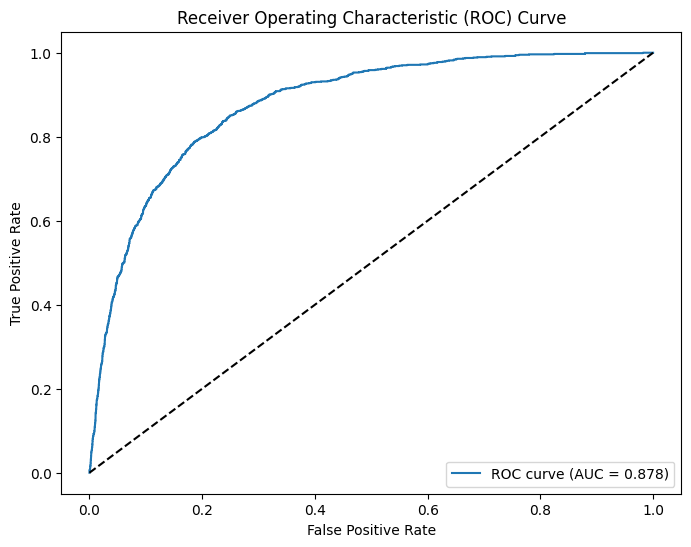

In [27]:
#Fitting a Logistic Regression Model for predicition based on relevant feature
# Suppress convergence warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

#Feature Selection and Data Preparation
# Select relevant features based on domain knowledge or feature importance
relevant_features = ['age', 'job', 'marital', 'education', 'balance', 'housing', 'loan', 'duration', 'campaign', 'poutcome']

# Separate categorical and numerical features
categorical_features = [feature for feature in relevant_features if df[feature].dtype == 'object']
numerical_features = [feature for feature in relevant_features if df[feature].dtype != 'object']
X = df[relevant_features]
y = df['success'] #Target Variable

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True, dtype=float)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=100)
#Compute class weigt to check for dataset imbalance
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))
#  Model Fitting
logreg = LogisticRegression(solver='lbfgs', max_iter=10000, class_weight=class_weights_dict)
logreg.fit(X_train, y_train)

# Coefficient Interpretation
coefficients = logreg.coef_[0]
intercept = logreg.intercept_[0]
feature_names = X_encoded.columns

print(f"Coefficients: {coefficients[0]:.4f}")
print(f"Intercept: {intercept:.4f}")

# Prediction and Evaluation
y_pred = logreg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)


print("\nAccuracy: {:.3f}".format(accuracy))
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

# Model Fit Assessment (using statsmodels for p-values)
X_train_sm = sm.add_constant(X_train)
logit_model = sm.Logit(y_train, X_train_sm).fit(disp=False)
print("\nStatsmodels Summary:")
print(logit_model.summary())


# ROC Curve and AUC
y_pred_proba = logreg.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random classifier
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

